# Baseline Behavior Sweep

This is one dated investigation notebook in a repeatable series -- see
`notebooks/experiments/README.md` for the full index and how later
investigations relate to this one. Each investigation gets its own
`<date>-<slug>.ipynb` file and is never edited in place once committed;
comparing kernel versions means comparing notebooks, not diffing one file's
history.

**Purpose.** Establish an empirical baseline for the simulation kernel
version recorded in the reproducibility header below: what kinds of behavior
does it actually produce, and how complex is the relationship between
configuration and outcome? This is not an attempt to optimize the simulation
or build general-purpose experiment infrastructure -- it is a controlled
parameter sweep, executed through the existing headless `execute_run()`
primitive, with repeated RNG seeds so scenario effects can be separated from
stochastic effects. The intended pattern for *any* investigation in this
series is: run the sweep below against a stable kernel commit, read off the
diagnostics, document findings and evidence-driven follow-up work, and --
once that follow-up lands in separate PRs -- start a new dated notebook
against the changed kernel and compare against this one's conclusions.

**Non-goals.** This notebook does not redesign the kernel, implement any
newly-discovered behavior, modify telemetry, or build reusable sweep
infrastructure. Sweep orchestration stays notebook-local for now; see the
closing section for what this investigation suggests should happen in
separate PRs, including when sweep code would be worth factoring into
something shared across investigation notebooks.


In [1]:
from __future__ import annotations

import copy
import os
import subprocess
import tempfile
from dataclasses import asdict
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

from simlab._merge import deep_merge
from simlab.runner import SCHEMA_VERSION, RunRequest, execute_run

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100

## Reproducibility header

Every notebook in `notebooks/experiments/` starts with this header. The
kernel and investigation notebooks are expected to evolve in separate PRs
(see the closing section), so the point of this header is a checkpoint: which
kernel version produced the results below, disambiguating this notebook from
others in the series. It is not meant to be a long-term git-history-
preservation mechanism.


In [2]:
def _git(*args: str) -> str:
    return subprocess.run(
        ["git", *args], capture_output=True, text=True, check=True
    ).stdout.strip()


git_branch = _git("rev-parse", "--abbrev-ref", "HEAD")
git_commit = _git("rev-parse", "HEAD")
git_dirty = bool(_git("status", "--porcelain"))

# Matches this file's own name (notebooks/experiments/<date>-<slug>.ipynb) --
# keep them in sync if this file is ever renamed.
EXPERIMENT_NAME = "2026-08-08-baseline-behavior-sweep"

print("Notebook reproducibility header")
print(f"  experiment_name : {EXPERIMENT_NAME}")
print(f"  executed_at_utc : {datetime.now(timezone.utc).isoformat()}")
print(f"  git_branch      : {git_branch}")
print(f"  git_commit      : {git_commit}")
print(f"  git_dirty       : {git_dirty}")
print(f"  schema_version  : {SCHEMA_VERSION}")

Notebook reproducibility header
  experiment_name : 2026-08-08-baseline-behavior-sweep
  executed_at_utc : 2026-08-08T17:14:24.874090+00:00
  git_branch      : notebook/baseline-behavior-sweep
  git_commit      : b4f53259e2714efabcdfafdacbbe7f95c948ea4c
  git_dirty       : True
  schema_version  : 0.1.0


## Sweep design

**Baseline scenario.** 60 agents, a single claim, moderate observation/noise
settings matching `configs/default.yaml`'s spirit (unbounded social
acceptance, static trust, verification as the strongest evidence channel).

**One-factor-at-a-time (OFAT) axes.** Exhaustively combining every candidate
parameter would produce a combinatorial explosion that stops being
interpretable. Instead, each axis below varies a single parameter away from
the baseline (low/high, or a qualitatively distinct mechanism state such as
"no trust adaptation" vs. "active trust adaptation"), holding everything else
fixed. This keeps the grid additive and small (17 configs) at the cost of not
exploring every combination.

**One interaction grid.** `confidence_bound x trust_update_rate` gets a full
3x3 grid, since bounded confidence and dynamic trust are the two mechanisms
with the clearest a-priori reason to interact (trust drift is computed from
agreement with heard evidence, and bounded confidence gates which evidence is
even considered).

**Structural scenarios.** Population size (small/large), profile composition
(homogeneous vs. the `configs/heterogeneous.yaml`-style attentive/distracted/
skeptical mix, scaled to the same total), and a "social-only" condition where
observation is disabled and `VERIFY`'s preference is set to 0 (making its
score `-cost`, always worse than `IDLE`'s score of `0`) so the *only* memory
type ever formed is `HEAR`, sourced from agents' own random initial beliefs.
This isolates bounded confidence / trust dynamics as a pure opinion-dynamics
process, free of a truth-seeking channel that would otherwise dominate the
outcome -- see "Mechanism activation" below for why that isolation turned out
to matter.

**Seeds.** 10 seeds per scenario config, so the unit of analysis is one
scenario x several stochastic replicates, not one run per point.


In [3]:
STEPS = 300
SEEDS = list(range(10))

BASELINE_CFG = {
    "world": {
        "rng_seed": 0,
        "truths": {0: True},
        "noise": {"OBSERVE": 0.1, "HEAR": 0.15, "VERIFY": 0.05},
        "observation": {"private_event_rate": 0.1, "global_event_rate": 0.0},
    },
    "agent": {
        "defaults": {
            "observation": {"attention": 1.0, "bias": 0.0},
            "trust": {"default": 0.5},
            "social": {
                "confidence_bound": 1.0,
                "trust_update_rate": 0.0,
                "update_trust_on_rejection": True,
            },
            "learning": {
                "rate": 0.1,
                "observe_weight": 0.6,
                "hear_weight": 0.3,
                "verify_weight": 1.0,
            },
            "action_preference": {
                "IDLE": 0.0,
                "VERIFY": 0.9,
                "COMMUNICATE": 0.7,
                "BROADCAST": 0.5,
            },
            "action_cost": {
                "IDLE": 0.0,
                "VERIFY": 0.35,
                "COMMUNICATE": 0.15,
                "BROADCAST": 0.30,
            },
        },
        "profiles": [{"name": "default", "count": 60}],
    },
}

OFAT_AXES: dict[str, list[tuple[str, dict]]] = {
    "confidence_bound": [  # baseline: 1.0 (unbounded acceptance)
        (
            "narrow_0.05",
            {"agent": {"defaults": {"social": {"confidence_bound": 0.05}}}},
        ),
        (
            "moderate_0.3",
            {"agent": {"defaults": {"social": {"confidence_bound": 0.3}}}},
        ),
    ],
    "trust_update_rate": [  # baseline: 0.0 (static trust)
        (
            "moderate_0.2",
            {"agent": {"defaults": {"social": {"trust_update_rate": 0.2}}}},
        ),
        ("fast_0.6", {"agent": {"defaults": {"social": {"trust_update_rate": 0.6}}}}),
    ],
    "default_trust": [  # baseline: 0.5
        ("low_0.1", {"agent": {"defaults": {"trust": {"default": 0.1}}}}),
        ("high_0.9", {"agent": {"defaults": {"trust": {"default": 0.9}}}}),
    ],
    "hear_weight": [  # baseline: 0.3
        ("off_0.0", {"agent": {"defaults": {"learning": {"hear_weight": 0.0}}}}),
        ("dominant_0.8", {"agent": {"defaults": {"learning": {"hear_weight": 0.8}}}}),
    ],
    "private_event_rate": [  # baseline: 0.1
        ("rare_0.02", {"world": {"observation": {"private_event_rate": 0.02}}}),
        ("frequent_0.4", {"world": {"observation": {"private_event_rate": 0.4}}}),
    ],
    "attention": [  # baseline: 1.0
        ("low_0.2", {"agent": {"defaults": {"observation": {"attention": 0.2}}}}),
        ("moderate_0.6", {"agent": {"defaults": {"observation": {"attention": 0.6}}}}),
    ],
    "noise_regime": [  # baseline: OBSERVE=0.1 HEAR=0.15 VERIFY=0.05
        ("none", {"world": {"noise": {"OBSERVE": 0.0, "HEAR": 0.0, "VERIFY": 0.0}}}),
        ("high", {"world": {"noise": {"OBSERVE": 0.3, "HEAR": 0.35, "VERIFY": 0.2}}}),
    ],
    "verify_cost": [  # baseline: 0.35
        ("cheap_0.1", {"agent": {"defaults": {"action_cost": {"VERIFY": 0.1}}}}),
        ("expensive_0.7", {"agent": {"defaults": {"action_cost": {"VERIFY": 0.7}}}}),
    ],
}

# Mirrors configs/heterogeneous.yaml's mix, scaled to the baseline's 60 agents.
HETEROGENEOUS_PROFILES = [
    {"name": "attentive", "count": 24, "observation": {"attention": 0.95}},
    {"name": "distracted", "count": 24, "observation": {"attention": 0.35}},
    {
        "name": "skeptical",
        "count": 12,
        "trust": {"default": 0.25},
        "learning": {"hear_weight": 0.15, "verify_weight": 1.2},
        "action_preference": {"VERIFY": 1.0, "COMMUNICATE": 0.35, "BROADCAST": 0.2},
    },
]

INTERACTION_CONFIDENCE = [0.05, 0.3, 1.0]
INTERACTION_TRUST_RATE = [0.0, 0.2, 0.6]


def build_scenarios() -> list[dict]:
    scenarios = [
        {
            "id": "baseline",
            "group": "baseline",
            "swept_axis": None,
            "label": "baseline",
            "cfg": BASELINE_CFG,
        }
    ]

    for axis, variants in OFAT_AXES.items():
        for label, overrides in variants:
            cfg = deep_merge(copy.deepcopy(BASELINE_CFG), overrides)
            scenarios.append(
                {
                    "id": f"{axis}:{label}",
                    "group": "ofat",
                    "swept_axis": axis,
                    "label": label,
                    "cfg": cfg,
                }
            )

    small = deep_merge(
        copy.deepcopy(BASELINE_CFG),
        {"agent": {"profiles": [{"name": "default", "count": 15}]}},
    )
    large = deep_merge(
        copy.deepcopy(BASELINE_CFG),
        {"agent": {"profiles": [{"name": "default", "count": 150}]}},
    )
    scenarios.append(
        {
            "id": "num_agents:small_15",
            "group": "structural",
            "swept_axis": "num_agents",
            "label": "small_15",
            "cfg": small,
        }
    )
    scenarios.append(
        {
            "id": "num_agents:large_150",
            "group": "structural",
            "swept_axis": "num_agents",
            "label": "large_150",
            "cfg": large,
        }
    )

    hetero = copy.deepcopy(BASELINE_CFG)
    hetero["agent"]["profiles"] = HETEROGENEOUS_PROFILES
    scenarios.append(
        {
            "id": "profile_composition:heterogeneous",
            "group": "structural",
            "swept_axis": "profile_composition",
            "label": "heterogeneous",
            "cfg": hetero,
        }
    )

    social_only_overrides = {
        "world": {"observation": {"private_event_rate": 0.0, "global_event_rate": 0.0}},
        "agent": {"defaults": {"action_preference": {"VERIFY": 0.0}}},
    }
    for cb, label in [(0.05, "narrow_cb"), (1.0, "wide_cb")]:
        cfg = deep_merge(
            copy.deepcopy(BASELINE_CFG),
            deep_merge(
                copy.deepcopy(social_only_overrides),
                {"agent": {"defaults": {"social": {"confidence_bound": cb}}}},
            ),
        )
        scenarios.append(
            {
                "id": f"social_only:{label}",
                "group": "structural",
                "swept_axis": "social_only",
                "label": label,
                "cfg": cfg,
            }
        )

    for cb in INTERACTION_CONFIDENCE:
        for tur in INTERACTION_TRUST_RATE:
            cfg = deep_merge(
                copy.deepcopy(BASELINE_CFG),
                {
                    "agent": {
                        "defaults": {
                            "social": {"confidence_bound": cb, "trust_update_rate": tur}
                        }
                    }
                },
            )
            scenarios.append(
                {
                    "id": f"interaction:cb={cb},tur={tur}",
                    "group": "interaction",
                    "swept_axis": "confidence_bound_x_trust_update_rate",
                    "label": f"cb={cb},tur={tur}",
                    "cfg": cfg,
                }
            )

    return scenarios


SCENARIOS = build_scenarios()
print(
    f"{len(SCENARIOS)} unique scenario configs x {len(SEEDS)} seeds = {len(SCENARIOS) * len(SEEDS)} runs"
)

31 unique scenario configs x 10 seeds = 310 runs


## Executing the sweep

Each scenario config is written to a temporary YAML file and run through
`execute_run()` unmodified -- no reimplementation of simulation execution or
telemetry collection. Run artifacts (`manifest.json`/`summary.json`/
`trajectory.csv`) are *not* persisted to `runs/` here to keep this exploratory
sweep from scattering hundreds of run directories through the repo; the
`result.scenario` and `result.summary` dicts already carry everything the
analysis below needs, and are assembled directly into a run-level table.
Full per-tick telemetry is kept only for one representative seed per scenario
(`seed=0`), for the trajectory-diversity plots near the end.


In [4]:
records = []
trajectories: dict[str, list] = {}  # scenario_id -> telemetry for seed 0

with tempfile.TemporaryDirectory() as tmpdir:
    for scenario in SCENARIOS:
        for seed in SEEDS:
            cfg = deep_merge(
                copy.deepcopy(scenario["cfg"]), {"world": {"rng_seed": seed}}
            )
            safe_name = (
                scenario["id"]
                .replace("/", "_")
                .replace(":", "_")
                .replace(",", "_")
                .replace("=", "")
            )
            path = os.path.join(tmpdir, f"{safe_name}_{seed}.yaml")
            with open(path, "w") as f:
                yaml.safe_dump(cfg, f)

            result = execute_run(RunRequest(config_path=path, steps=STEPS))

            records.append(
                {
                    "scenario_id": scenario["id"],
                    "scenario_group": scenario["group"],
                    "swept_axis": scenario["swept_axis"],
                    "label": scenario["label"],
                    "seed": seed,
                    "run_id": result.metadata.run_id,
                    "scenario_fingerprint": result.metadata.scenario_fingerprint,
                    "run_spec_fingerprint": result.metadata.run_spec_fingerprint,
                    **result.scenario,
                    **asdict(result.summary),
                }
            )

            if seed == 0:
                trajectories[scenario["id"]] = result.telemetry

runs = pd.DataFrame(records)
print(f"Analysis dataset: {runs.shape[0]} runs x {runs.shape[1]} columns")
runs.head()

Analysis dataset: 310 runs x 182 columns


,scenario_id,scenario_group,swept_axis,label,seed,run_id,scenario_fingerprint,run_spec_fingerprint,num_agents,num_claims,private_event_rate,global_event_rate,noise.OBSERVE,noise.HEAR,noise.VERIFY,graph.num_nodes,graph.num_edges,graph.edge_density,graph.mean_out_degree,graph.std_out_degree,graph.min_out_degree,graph.max_out_degree,graph.fraction_isolated,graph.adjacency_fingerprint,profile_count.default,profile_fraction.default,agent_attention_mean,agent_attention_std,agent_bias_mean,agent_bias_std,...,agent_profile.distracted.confidence_bound,agent_profile.distracted.trust_update_rate,agent_profile.distracted.update_trust_on_rejection,agent_profile.distracted.action_preference.IDLE,agent_profile.distracted.action_cost.IDLE,agent_profile.distracted.action_preference.VERIFY,agent_profile.distracted.action_cost.VERIFY,agent_profile.distracted.action_preference.COMMUNICATE,agent_profile.distracted.action_cost.COMMUNICATE,agent_profile.distracted.action_preference.BROADCAST,agent_profile.distracted.action_cost.BROADCAST,agent_profile.skeptical.order_index,agent_profile.skeptical.attention,agent_profile.skeptical.bias,agent_profile.skeptical.learning_rate,agent_profile.skeptical.observe_weight,agent_profile.skeptical.hear_weight,agent_profile.skeptical.verify_weight,agent_profile.skeptical.default_trust,agent_profile.skeptical.confidence_bound,agent_profile.skeptical.trust_update_rate,agent_profile.skeptical.update_trust_on_rejection,agent_profile.skeptical.action_preference.IDLE,agent_profile.skeptical.action_cost.IDLE,agent_profile.skeptical.action_preference.VERIFY,agent_profile.skeptical.action_cost.VERIFY,agent_profile.skeptical.action_preference.COMMUNICATE,agent_profile.skeptical.action_cost.COMMUNICATE,agent_profile.skeptical.action_preference.BROADCAST,agent_profile.skeptical.action_cost.BROADCAST
0,baseline,baseline,NaN,baseline,0,8b0ae53b9918472faca58114e78ce432,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,4b4a97a6655493e39082f8a6d2f9b4946dcc1ce628e0c6...,60,1,0.1,0.0,0.1,0.15,0.05,60,125,0.035311,2.083333,1.508771,0,4,0.183333,1094256658584309360,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline,baseline,NaN,baseline,1,fda3b7687718491dafc8af76b0c22d5e,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,67d5c0ac6384a1a1e489fdb2560e1f388c2de59c48ebf2...,60,1,0.1,0.0,0.1,0.15,0.05,60,136,0.038418,2.266667,1.481741,0,4,0.166667,10023458850868456750,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline,baseline,NaN,baseline,2,a93a603bc4f8447a81dbc2cef762fe09,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,30d3451319c69c38fa7db3936fd8a5061207f84ea2d92b...,60,1,0.1,0.0,0.1,0.15,0.05,60,107,0.030226,1.783333,1.592604,0,4,0.316667,7592705126979031321,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline,baseline,NaN,baseline,3,71dedddc8aa84e3eaa03e97cbaffbc11,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,3665632d046cce9be92f067b09d79d0095321fd12a5bc2...,60,1,0.1,0.0,0.1,0.15,0.05,60,138,0.038983,2.300000,1.405940,0,4,0.133333,11803418477097846842,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline,baseline,NaN,baseline,4,7fe99eb112ab4d6f95b567b67fc5682c,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,20bb391fbea24afd4a978d60af8470b540851a3b0d594e...,60,1,0.1,0.0,0.1,0.15,0.05,60,106,0.029944,1.766667,1.358512,0,4,0.250000,5466998976349032876,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Outcome diversity

Split the dataset into the 29 truth-anchored scenarios (290 runs -- everything
except `social_only`) and the 2 social-only scenarios (20 runs), since they
turn out to be qualitatively different regimes.


Label rates, truth-anchored scenarios (n=290):
converged                0.921
final_consensus          0.993
final_truth_aligned      1.000
final_false_consensus    0.000

Label rates, social-only scenarios (n=20):
converged                0.0
final_consensus          0.0
final_truth_aligned      0.0
final_false_consensus    0.0


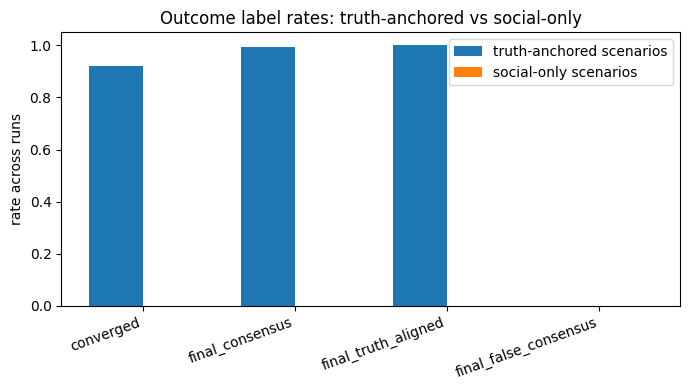

In [5]:
label_cols = [
    "converged",
    "final_consensus",
    "final_truth_aligned",
    "final_false_consensus",
]
truth_anchored = runs[runs.swept_axis != "social_only"]
social_only = runs[runs.swept_axis == "social_only"]

print(f"Label rates, truth-anchored scenarios (n={len(truth_anchored)}):")
print(truth_anchored[label_cols].mean().round(3).to_string())
print(f"\nLabel rates, social-only scenarios (n={len(social_only)}):")
print(social_only[label_cols].mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(label_cols))
width = 0.35
ax.bar(
    x - width / 2,
    truth_anchored[label_cols].mean(),
    width,
    label="truth-anchored scenarios",
)
ax.bar(
    x + width / 2, social_only[label_cols].mean(), width, label="social-only scenarios"
)
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=20, ha="right")
ax.set_ylabel("rate across runs")
ax.set_title("Outcome label rates: truth-anchored vs social-only")
ax.legend()
plt.tight_layout()
plt.show()

**Reading this:** when *any* truth-grounded channel is present (observation
and/or verification, however sparse), the kernel produces essentially one
outcome regime: `final_truth_aligned` is `True` in all 290 truth-anchored
runs, `final_consensus` in 99.3% of them, and `final_false_consensus` never
occurs. That's a strong, single-regime result -- not a weakness by itself
(see the closing conclusion), but it means the *truth-anchored* operating
region explored here doesn't exhibit persistent disagreement or confidently-
wrong consensus on its own.

Removing the truth-grounded channel entirely (`social_only`) flips this
completely: `converged`, `final_consensus`, and `final_truth_aligned` all drop
to 0%. This is the only condition in the whole sweep where the population
does *not* end up truth-aligned -- see "Mechanism activation" below for what
it looks like instead.


## Scenario signal vs. stochastic noise

For each outcome metric, decompose total variance across the truth-anchored
runs into a between-scenario share (`SS_between / SS_total`, a one-way ANOVA
style decomposition treating `scenario_id` as the grouping factor) and a
within-scenario (seed) share.


  final_mean_truth_error: 0.993
  final_mean_claim_belief_variance: 0.350
  mean_belief_volatility: 0.923
  convergence_tick: 0.596


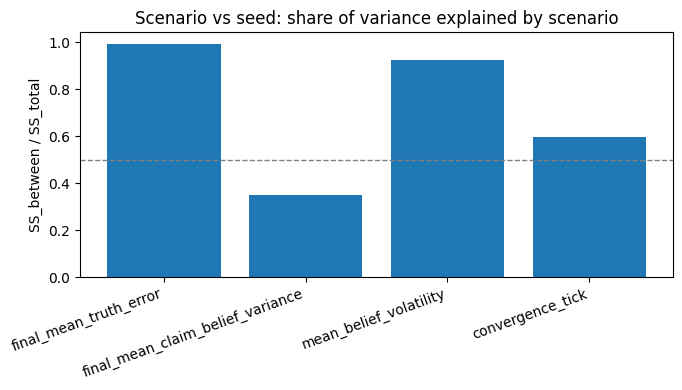

In [6]:
def between_scenario_variance_share(df: pd.DataFrame, metric: str) -> float:
    sub = df[["scenario_id", metric]].dropna()
    grand_mean = sub[metric].mean()
    group_means = sub.groupby("scenario_id")[metric].mean()
    group_sizes = sub.groupby("scenario_id")[metric].size()
    ss_between = float((group_sizes * (group_means - grand_mean) ** 2).sum())
    ss_total = float(((sub[metric] - grand_mean) ** 2).sum())
    return ss_between / ss_total if ss_total else float("nan")


variance_metrics = [
    "final_mean_truth_error",
    "final_mean_claim_belief_variance",
    "mean_belief_volatility",
    "convergence_tick",
]
variance_shares = {
    m: between_scenario_variance_share(truth_anchored, m) for m in variance_metrics
}
for m, v in variance_shares.items():
    print(f"  {m}: {v:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(variance_shares.keys()), list(variance_shares.values()), color="tab:blue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("SS_between / SS_total")
ax.set_title("Scenario vs seed: share of variance explained by scenario")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Reading this:** `final_mean_truth_error` is almost entirely scenario-driven
(99.3%) -- for a fixed configuration, the final truth error is highly
reproducible across seeds. `mean_belief_volatility` is similarly
scenario-dominated (92.3%). `convergence_tick` (59.6%) has a sizeable
seed-driven component, consistent with convergence being a threshold-crossing
event whose exact timing is sensitive to stochastic details even when the
scenario is fixed. `final_mean_claim_belief_variance` is the outlier (35%
scenario share) -- but that metric sits extremely close to 0 in almost every
truth-anchored scenario (agents agree), so small absolute fluctuations
dominate its variance without being practically meaningful. Overall: this is
a landscape with real, reproducible scenario-level structure, not just noise.


## Parameter response

Mean final truth error for each OFAT axis's baseline + 2 variants (error bars
= std across the 10 seeds).


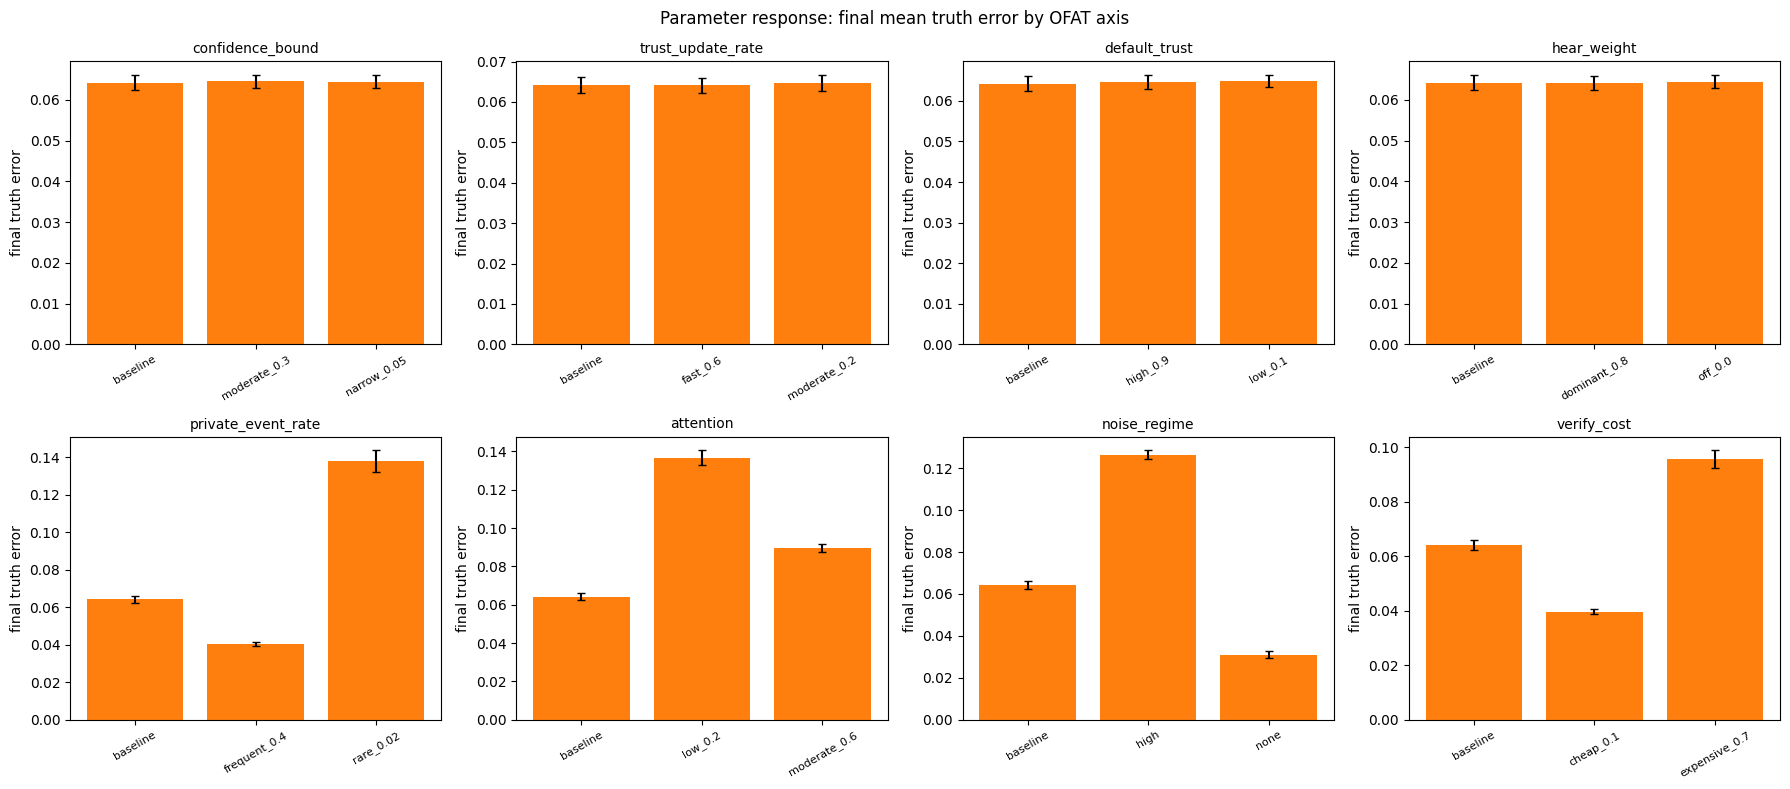

In [7]:
ofat = runs[runs.scenario_group.isin(["baseline", "ofat"])]
axes_list = list(ofat.swept_axis.dropna().unique())

fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
for ax, axis in zip(axs.flat, axes_list):
    sub = pd.concat(
        [ofat[ofat.scenario_id == "baseline"], ofat[ofat.swept_axis == axis]]
    )
    grouped = sub.groupby("label")["final_mean_truth_error"].agg(["mean", "std"])
    grouped = grouped.reindex(
        sorted(grouped.index, key=lambda label: (label != "baseline", label))
    )
    ax.bar(
        grouped.index,
        grouped["mean"],
        yerr=grouped["std"],
        capsize=3,
        color="tab:orange",
    )
    ax.set_title(axis, fontsize=10)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
    ax.set_ylabel("final truth error")
fig.suptitle("Parameter response: final mean truth error by OFAT axis")
plt.tight_layout()
plt.show()

**Reading this:** the eight axes split cleanly into two groups.

- **Channel-strength parameters** (`private_event_rate`, `attention`,
  `noise_regime`, `verify_cost`) move final truth error a lot -- roughly a
  4-5x range, from ~0.03 (no noise / frequent events) to ~0.14 (rare events /
  low attention / high noise). These directly control how much truth-grounded
  evidence reaches agents at all, or how reliable it is.
- **Purely social parameters** (`confidence_bound`, `trust_update_rate`,
  `default_trust`, `hear_weight`) move it almost imperceptibly -- differences
  of ~0.0005 against a seed std of ~0.002, i.e. within noise. Going from
  unbounded acceptance to a very narrow bound, or from static to fast-adapting
  trust, barely changes *how accurate the population ends up*.

That second finding looks at first like "these mechanisms don't matter," but
"Mechanism activation" below shows that's only true when a truth-grounded
channel is present at all -- the mechanisms are active, just outcome-dormant
in this regime.


## Predictability with simple vs. nonlinear models

Simple models (linear/logistic regression) and a random forest are used here
purely as landscape probes, not to be optimized -- the question is whether a
model that can only combine parameters additively captures most of the
predictable structure, or whether a model that can represent interactions and
thresholds does meaningfully better.


final_mean_truth_error ~ swept params -- 5-fold CV R^2
  LinearRegression: 0.732 +- 0.114
  RandomForest:     0.990 +- 0.004


converged ~ swept params -- 5-fold CV accuracy (majority baseline = 0.921)
  LogisticRegression: 0.921
  RandomForest:       0.990


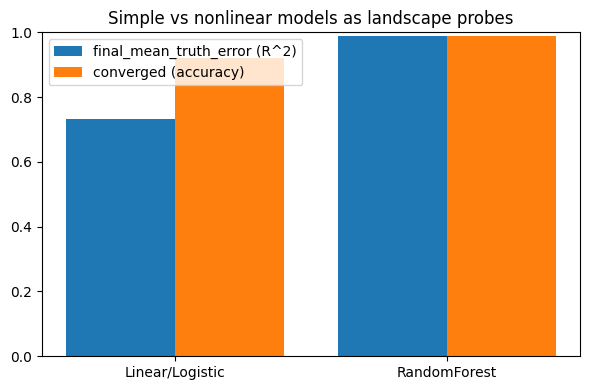

In [8]:
feature_cols = [
    "agent_confidence_bound_mean",
    "agent_trust_update_rate_mean",
    "agent_default_trust_mean",
    "agent_hear_weight_mean",
    "private_event_rate",
    "agent_attention_mean",
    "noise.OBSERVE",
    "noise.HEAR",
    "noise.VERIFY",
    "agent_action_cost.VERIFY_mean",
    "num_agents",
]
model_df = truth_anchored.dropna(subset=feature_cols + ["final_mean_truth_error"])
X = model_df[feature_cols].values
y = model_df["final_mean_truth_error"].values

kf = KFold(n_splits=5, shuffle=True, random_state=0)
lin_r2 = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
rf_r2 = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=0), X, y, cv=kf, scoring="r2"
)
print("final_mean_truth_error ~ swept params -- 5-fold CV R^2")
print(f"  LinearRegression: {lin_r2.mean():.3f} +- {lin_r2.std():.3f}")
print(f"  RandomForest:     {rf_r2.mean():.3f} +- {rf_r2.std():.3f}")

y_bin = model_df["converged"].astype(int).values
logit_acc = rf_acc = None
if len(np.unique(y_bin)) > 1:
    logit_acc = cross_val_score(
        LogisticRegression(max_iter=1000), X, y_bin, cv=kf, scoring="accuracy"
    )
    rf_acc = cross_val_score(
        RandomForestClassifier(n_estimators=200, random_state=0),
        X,
        y_bin,
        cv=kf,
        scoring="accuracy",
    )
    print(
        f"converged ~ swept params -- 5-fold CV accuracy (majority baseline = {max(y_bin.mean(), 1 - y_bin.mean()):.3f})"
    )
    print(f"  LogisticRegression: {logit_acc.mean():.3f}")
    print(f"  RandomForest:       {rf_acc.mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
labels_ = ["Linear/Logistic", "RandomForest"]
bars_x = np.arange(2)
ax.bar(
    bars_x - 0.2,
    [lin_r2.mean(), rf_r2.mean()],
    width=0.4,
    label="final_mean_truth_error (R^2)",
)
if logit_acc is not None:
    ax.bar(
        bars_x + 0.2,
        [logit_acc.mean(), rf_acc.mean()],
        width=0.4,
        label="converged (accuracy)",
    )
ax.set_xticks(bars_x)
ax.set_xticklabels(labels_)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Simple vs nonlinear models as landscape probes")
plt.tight_layout()
plt.show()

**Reading this:** linear regression explains 73% of cross-validated variance
in final truth error; the random forest explains 99%. That gap suggests
real nonlinear structure -- but it comes with an important design caveat:
because the grid is OFAT (each row shares the baseline value on 10 of 11
features and differs on just one), a random forest can partly succeed by
memorizing "which single-axis cluster" a row belongs to rather than learning
genuine curvature in the response surface. A broader random/Latin-hypercube
design that actually varies multiple parameters at once per run would be
needed to confirm how much of this gap is real nonlinearity vs. an artifact
of the OFAT design -- flagged in the follow-up section. For the binary
`converged` label, the random forest (99%) clears the logistic
regression/majority-baseline tie (both 92.1%) by a real margin, which is a
weaker but still real hint of threshold-like structure (consistent with
`private_event_rate:frequent_0.4` and `noise_regime:high` never registering
as "converged" despite being fully truth-aligned -- see "Mechanism
activation").


## Interaction: bounded confidence x dynamic trust

The one parameter pair with a clear a-priori interaction hypothesis, at a
full 3x3 grid.


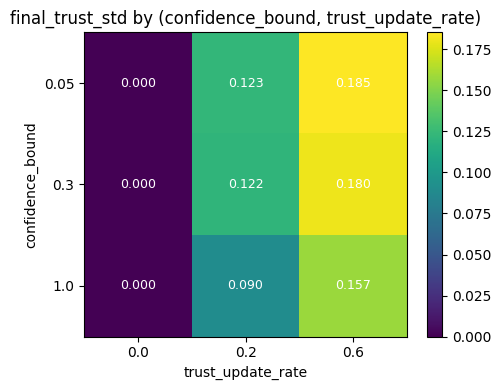

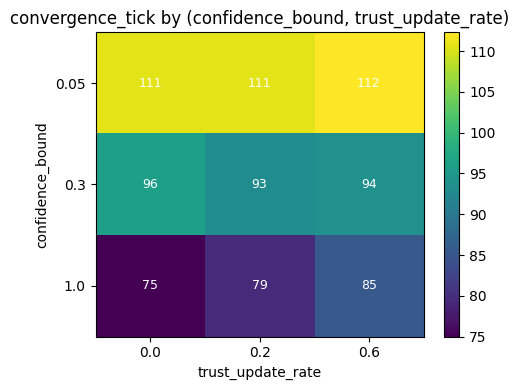

In [9]:
interaction = runs[runs.scenario_group == "interaction"]


def interaction_heatmap(metric: str, title: str, fmt="{:.3f}"):
    pivot = interaction.pivot_table(
        index="agent_confidence_bound_mean",
        columns="agent_trust_update_rate_mean",
        values=metric,
        aggfunc="mean",
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("trust_update_rate")
    ax.set_ylabel("confidence_bound")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(
                j,
                i,
                fmt.format(pivot.values[i, j]),
                ha="center",
                va="center",
                color="white",
                fontsize=9,
            )
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    return pivot


pivot_trust_std = interaction_heatmap(
    "final_trust_std", "final_trust_std by (confidence_bound, trust_update_rate)"
)
pivot_conv_tick = interaction_heatmap(
    "convergence_tick",
    "convergence_tick by (confidence_bound, trust_update_rate)",
    fmt="{:.0f}",
)

**Reading this:** `final_trust_std` (how much trust in different sources
diverges) is exactly 0 whenever `trust_update_rate=0` (trust is static by
construction), then increases with `trust_update_rate` as expected -- and,
for a fixed `trust_update_rate`, is consistently *higher* under a narrower
confidence bound (e.g. at `trust_update_rate=0.6`: 0.185 at `cb=0.05` vs 0.157
at `cb=1.0`). That's a real, mechanistically sensible interaction: a narrow
bound rejects more heard evidence, so agents differentiate trust across
sources more sharply. `convergence_tick` shows a related pattern: convergence
is consistently slower under a narrower bound (110.8 ticks at `cb=0.05,
tur=0` vs. 75.0 at `cb=1.0, tur=0`), and increasing `trust_update_rate`
slightly *slows* convergence at wide bounds (75.0 -> 85.4) but has almost no
effect at narrow bounds (110.8 -> 112.3). So these two mechanisms visibly
interact at the *process* level (trust dispersion, convergence speed) even
though neither moves final truth error much (see "Parameter response").

## Mechanism activation

A mechanism being implemented doesn't mean it's doing anything in a typical
run. Compare agent-tick activity fractions across a few scenarios, including
`social_only`, where -- unlike every truth-anchored scenario -- bounded
confidence is the *only* thing shaping the outcome.


                              trust_update_frac  verify_frac  communicate_frac  broadcast_frac  observe_frac
scenario_id                                                                                                 
baseline                                 0.0000       0.0307            0.0155             0.0        0.1002
confidence_bound:narrow_0.05             0.0000       0.0283            0.0514             0.0        0.0997
trust_update_rate:fast_0.6               0.0147       0.0301            0.0172             0.0        0.1003
social_only:narrow_cb                    0.0000       0.0000            0.3067             0.0        0.0000


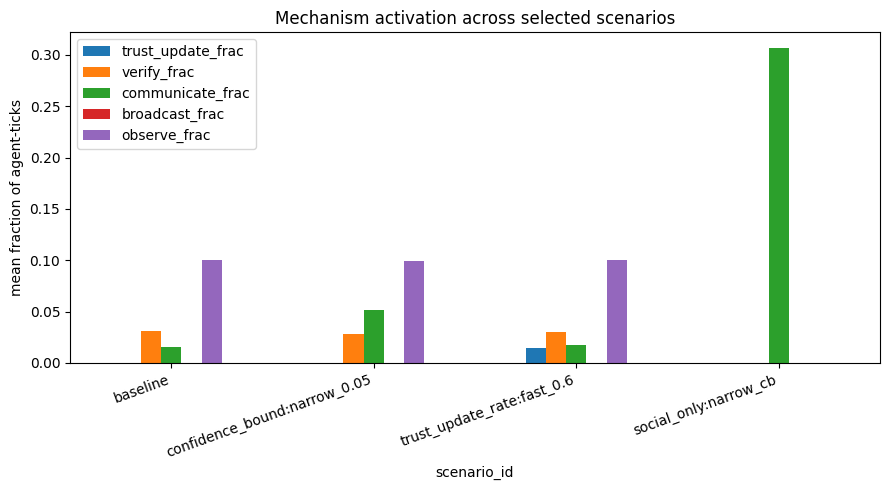

In [10]:
mech = runs.copy()
denom = mech["num_agents"] * STEPS
mech["trust_update_frac"] = mech["total_trust_updating_agent_ticks"] / denom
mech["verify_frac"] = mech["total_verifications"] / denom
mech["communicate_frac"] = mech["total_communicate_edges"] / denom
mech["broadcast_frac"] = mech["total_broadcast_edges"] / denom
mech["observe_frac"] = mech["total_observations"] / denom

mech_scenarios = [
    "baseline",
    "confidence_bound:narrow_0.05",
    "trust_update_rate:fast_0.6",
    "social_only:narrow_cb",
]
mech_summary = (
    mech[mech.scenario_id.isin(mech_scenarios)]
    .groupby("scenario_id")[
        [
            "trust_update_frac",
            "verify_frac",
            "communicate_frac",
            "broadcast_frac",
            "observe_frac",
        ]
    ]
    .mean()
    .reindex(mech_scenarios)
)
print(mech_summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
mech_summary.plot(kind="bar", ax=ax)
ax.set_ylabel("mean fraction of agent-ticks")
ax.set_title("Mechanism activation across selected scenarios")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Reading this:** `trust_update_frac` is exactly 0 whenever `trust_update_rate=0`
(mechanically guaranteed) and jumps to ~0.015 (baseline population, mixed
trust rates across the sweep) when active -- trust dynamics are inert unless
explicitly turned on, as designed. More interestingly, `communicate_frac`
roughly triples under a narrow confidence bound relative to baseline (0.051
vs. 0.016): rejecting more heard evidence keeps local disagreement higher for
longer, which the action-scoring heuristic (`preference * confidence *
disagreement - cost`) rewards with more `COMMUNICATE` attempts. So bounded
confidence *is* mechanically active -- it changes what agents do -- even
though "Parameter response" showed it barely changes the final truth-error
outcome. The `social_only:narrow_cb` scenario makes the reason legible:
`verify_frac` and `observe_frac` are exactly 0 (both channels are disabled by
construction) and `communicate_frac` is 0.307 -- roughly 6-20x every other
scenario shown, because with no truth-grounded evidence ever accepted or
generated, `COMMUNICATE` is essentially the only thing agents ever do. Under
that condition (see "Outcome diversity"), the population does *not* converge:
final truth error sits at ~0.52-0.53 (chance level, since there was never a
truth signal to converge to), and final disagreement is markedly higher under
a narrow bound (0.075) than a wide one (0.053) -- the population fragments
around its initial random opinions rather than averaging toward one. That's
the textbook bounded-confidence fragmentation result, and it only shows up
once the truth-grounded channel that otherwise dominates the outcome is
removed.

## Trajectory diversity

Final-state outcomes can hide very different paths. Compare five
representative seed-0 trajectories: the fastest- and slowest-converging OFAT
variants, a variant that never formally registers as "converged," and the
social-only condition.


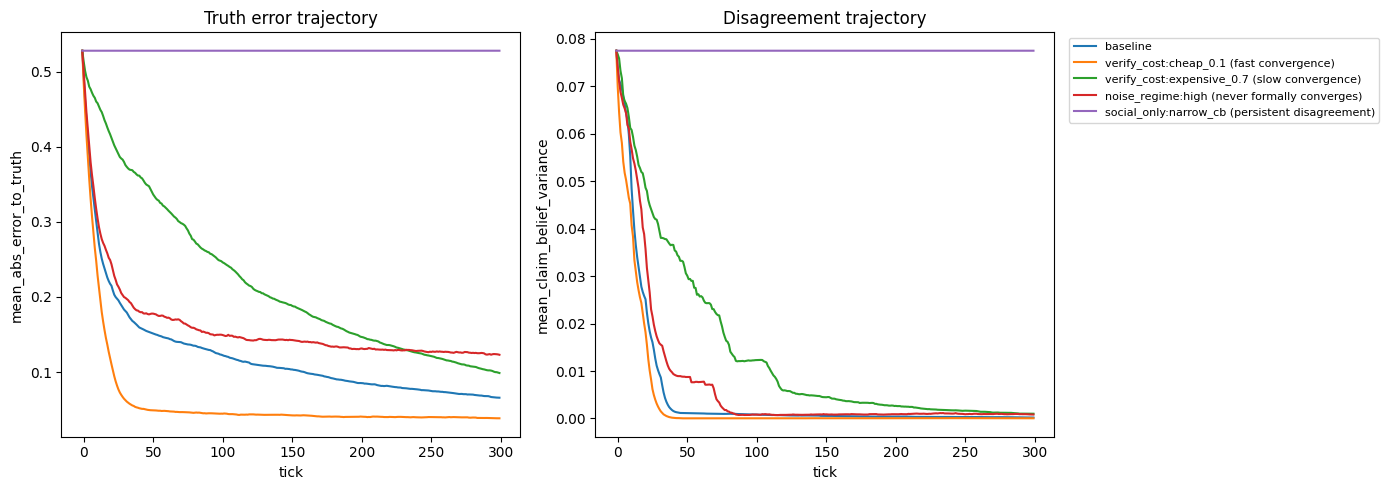

In [11]:
representative = {
    "baseline": "baseline",
    "verify_cost:cheap_0.1 (fast convergence)": "verify_cost:cheap_0.1",
    "verify_cost:expensive_0.7 (slow convergence)": "verify_cost:expensive_0.7",
    "noise_regime:high (never formally converges)": "noise_regime:high",
    "social_only:narrow_cb (persistent disagreement)": "social_only:narrow_cb",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for display_label, scenario_id in representative.items():
    rows = trajectories[scenario_id]
    ticks = [r.tick for r in rows]
    ax1.plot(ticks, [r.mean_abs_error_to_truth for r in rows], label=display_label)
    ax2.plot(ticks, [r.mean_claim_belief_variance for r in rows], label=display_label)
ax1.set_xlabel("tick")
ax1.set_ylabel("mean_abs_error_to_truth")
ax1.set_title("Truth error trajectory")
ax2.set_xlabel("tick")
ax2.set_ylabel("mean_claim_belief_variance")
ax2.set_title("Disagreement trajectory")
ax2.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

**Reading this:** `verify_cost:cheap` drops truth error almost immediately and
flattens by ~tick 50; `verify_cost:expensive` declines steadily but hasn't
fully flattened even by tick 300 (mean truth error still ~0.10, roughly 2.5x
the cheap variant's), a genuinely different trajectory *shape*, not just a
shifted copy of the same curve. `noise_regime:high` declines quickly at first
but then plateaus around ~0.13 with visible residual jitter -- it settles
into a stable-but-noisy regime rather than a quiet one, which is exactly why
`find_convergence_tick`'s stability window never triggers for it (see
"Predictability"). `social_only:narrow_cb` is flat from tick 0: with a
0.05-wide bound between two independently-random initial beliefs, very few
`HEAR` messages ever land inside the bound, so almost nothing gets accepted
and belief barely drifts over the full 300 ticks -- the population is
effectively frozen near its initial disagreement rather than slowly
converging.

## Conclusions

**Behavioral outcomes.** Whenever any truth-grounded evidence channel is
present -- even a sparse one (`private_event_rate=0.02`) or a noisy one
(`noise_regime=high`) -- the kernel produces one overwhelmingly dominant
regime across this entire grid: rapid-to-moderate truth-aligned consensus.
`final_truth_aligned=True` in 100% of 290 truth-anchored runs,
`final_false_consensus` in 0%, and `final_consensus` in 99.3%. Convergence
speed (measured by `convergence_tick`, when it registers at all) ranges from
~42 ticks (cheap verification) to ~218 ticks (expensive verification), a
~5x spread driven almost entirely by channel-strength parameters. Persistent
disagreement and non-truth-aligned outcomes do occur in this sweep, but only
in the `social_only` boundary condition where the truth-grounded channel is
removed entirely -- within the normal explored operating range, they don't.

**Variability.** Between-scenario variance dominates within-scenario (seed)
variance for the metrics that matter most (`final_mean_truth_error`: 99.3%
scenario-driven; `mean_belief_volatility`: 92.3%), meaning a given
configuration's outcome is highly reproducible across stochastic replicates.
`convergence_tick` has a real seed-driven component (59.6% scenario share),
consistent with it being a threshold-crossing event.

**Mechanisms.** Channel-strength parameters (`private_event_rate`,
`attention`, noise, `verify_cost`) materially influence final truth error --
a 4-5x range across their tested values. Bounded confidence and dynamic
trust are a more nuanced story: they visibly change *process*-level behavior
(communicate volume roughly triples under a narrow bound; trust dispersion
scales with `trust_update_rate` and is higher under narrower bounds) but
barely move the *final* truth-error outcome (differences within seed noise)
as long as any truth-grounded channel exists to eventually pull the
population toward truth regardless of the social path taken. Isolating them
in the `social_only` condition confirms they are not dormant in general --
narrower bounded confidence produces measurably higher persistent
disagreement (0.075 vs. 0.053) than an unbounded one when it's the *only*
mechanism operating.

**Complexity.** A random forest explains far more cross-validated variance in
final truth error (R^2=0.99) than a linear model (R^2=0.73), and clears a
majority-baseline tie for the `converged` label where logistic regression
cannot -- both consistent with real nonlinear/threshold structure, most
concretely the scenarios where a persistently-active-but-accurate population
never satisfies the "quiet for 20 ticks" convergence definition. That gap is
also partly an artifact of the OFAT design (see the predictability section's
caveat) and shouldn't be taken as a precise nonlinearity measurement.
Trajectories that reach similar final states can take visibly different
shapes and speeds (cheap vs. expensive verification), and a stable-but-noisy
regime (`noise_regime:high`) is visually and mechanically distinct from a
truly quiet one.

**Next direction.** The current kernel's *truth-anchored* operating region is
behaviorally narrow -- one dominant regime, with social parameters mostly
outcome-inert -- but that narrowness looks channel-driven rather than kernel-
wide: the `social_only` boundary condition shows the kernel is capable of
producing a qualitatively different regime (persistent fragmentation) once
the dominant truth-seeking channel is removed. That's evidence for
*investigating the boundary* (weaker channels, multiple/conflicting claims,
or population splits where only some agents have a truth-grounded channel)
before concluding the kernel itself needs new mechanisms -- see follow-up
work below.


## Follow-up work

Evidence-driven candidates for separate PRs, not implemented here.

**Telemetry PRs**
- Record `HEAR` acceptance/rejection counts directly (this notebook inferred
  bounded-confidence activation indirectly, from `communicate_frac` shifts,
  because acceptance/rejection isn't in `TelemetryRow` today).
- Record trust-update *magnitude*, not just whether trust changed --
  `final_trust_std` was a useful proxy here but a direct per-tick signal
  would be more precise.

**Run-analysis PRs**
- Refine `find_convergence_tick`: several scenarios (`private_event_rate:
  frequent_0.4`, `noise_regime:high`) never register as "converged" despite
  reaching stable, truth-aligned consensus, because persistent low-amplitude
  activity keeps `mean_abs_delta` above the delta threshold. A "stable around
  a fixed point despite residual jitter" definition would separate this from
  genuine non-convergence.
- The current `converged`/`final_consensus` labels conflate "settled" with
  "quiet"; a population that's accurate but persistently active never counts
  as converged under the current definition.

**Kernel PRs**
- This sweep only tested a single, always-true claim. Multiple or
  conflicting claims, or a population where only a subset of agents have
  access to a truth-grounded channel, are natural next probes for whether the
  kernel can produce richer behavior than the single dominant regime seen
  here.

**Experiment-infrastructure PRs**
- A broader random/Latin-hypercube sampling design (varying several
  parameters per run rather than one-at-a-time) would let the predictability
  probe distinguish genuine nonlinear response surfaces from the OFAT
  clustering artifact flagged above.
- If a later investigation notebook in `notebooks/experiments/` ends up
  repeating substantial chunks of this one's scenario-building/execution/
  analysis-dataset code unchanged, that repetition is the signal to factor
  it into a shared, importable module rather than copy-pasting cells again.

**Whenever a new investigation notebook is added:** append a row to
`notebooks/experiments/README.md` (date, file, kernel commit, one-line
finding) so the series stays browsable without digging through git history.
